In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import textwrap
import os

%matplotlib inline
sns.set(style="whitegrid", color_codes=True)

plt.rcParams['font.family'] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
plt.rcParams['font.size'] = 7

plt.rcParams['text.color'] = 'black'         # Text (titles, labels, etc.)
plt.rcParams['xtick.color'] = 'black'        # X-axis tick labels
plt.rcParams['ytick.color'] = 'black'        # Y-axis tick labels
# plt.rcParams['axes.labelcolor'] = 'black'    # Axis labels
plt.rcParams['axes.edgecolor'] = 'black'     # Axis edge (spines)
# plt.rcParams['legend.edgecolor'] = 'black'   # Legend border

In [17]:
result_dir = "/lustre/scratch/shared-folders/bio_project/shuxian/gbft/mg/rna_202507/RNAGym/fitness_prediction/performance"
result_path = os.path.join(result_dir, "results_by_rna_type.csv")
fitness = pd.read_csv(result_path)
fitness = fitness.iloc[:, :7]
fitness

,Model,Spearman_mRNA-splicing_Mean,Spearman_mRNA-coding_Mean,Spearman_tRNA_Mean,Spearman_Aptamer_Mean,Spearman_Ribozyme_Mean,Spearman_All_Mean
0,evo1_score,0.133845,0.160823,0.155498,0.034535,0.136566,0.124254
1,evo1.5_score,0.131077,0.157303,0.384997,0.043954,0.169016,0.177269
2,evo2_score,0.431365,0.270436,0.386735,0.119205,0.172115,0.275971
3,GenSLM_score,0.173388,0.083511,0.093373,0.125714,0.135365,0.122270
4,NT_score,0.120814,0.082897,0.316607,0.146460,0.146615,0.162679
5,rinalmo_score,0.348358,0.070085,0.259706,0.025864,0.072228,0.155248
6,RNAErnie_score,0.230081,0.117475,0.416115,0.037492,0.141794,0.188591
7,RNA-FM_score,0.103378,0.129171,0.463768,0.190264,0.200836,0.217483
8,aido_rna_1b600m_cds-wt-marginals_score,0.132377,0.201075,0.485615,0.144956,0.212251,0.235255
9,aido_rna_1b600m-wt-marginals_score,0.157137,0.078221,0.411209,0.169109,0.163542,0.195844


In [18]:
fitness.Model = ['Evo 1', 'Evo 1.5', 'Evo 2', 'GenSLM',
       'Nucl. Transformer', 'RiNALMo', 'RNAErnie', 'RNA-FM',
       'AIDO.RNA-CDS', 'AIDO.RNA',
       'AIDO.RNA-650M-CDS', 'AIDO.RNA-650M']
fitness.columns = ['Model', 'mRNA-splicing', 'mRNA-coding', 'tRNA', 'Aptamer', 'Ribozyme', 'All']
fitness["Model Cate."] = ["DNA FM"]*5 + ["RNA FM"]*7
fitness

,Model,mRNA-splicing,mRNA-coding,tRNA,Aptamer,Ribozyme,All,Model Cate.
0,Evo 1,0.133845,0.160823,0.155498,0.034535,0.136566,0.124254,DNA FM
1,Evo 1.5,0.131077,0.157303,0.384997,0.043954,0.169016,0.177269,DNA FM
2,Evo 2,0.431365,0.270436,0.386735,0.119205,0.172115,0.275971,DNA FM
3,GenSLM,0.173388,0.083511,0.093373,0.125714,0.135365,0.122270,DNA FM
4,Nucl. Transformer,0.120814,0.082897,0.316607,0.146460,0.146615,0.162679,DNA FM
5,RiNALMo,0.348358,0.070085,0.259706,0.025864,0.072228,0.155248,RNA FM
6,RNAErnie,0.230081,0.117475,0.416115,0.037492,0.141794,0.188591,RNA FM
7,RNA-FM,0.103378,0.129171,0.463768,0.190264,0.200836,0.217483,RNA FM
8,AIDO.RNA-CDS,0.132377,0.201075,0.485615,0.144956,0.212251,0.235255,RNA FM
9,AIDO.RNA,0.157137,0.078221,0.411209,0.169109,0.163542,0.195844,RNA FM


In [19]:
fitness = fitness.iloc[:10]  # drop AIDO.RNA-650M

reorder = ['AIDO.RNA-CDS', 'AIDO.RNA', 'RNA-FM', 'RNAErnie', 'RiNALMo',
            'GenSLM', 'Nucl. Transformer', 'Evo 1', 'Evo 1.5', 'Evo 2']
# sort data by reorder
fitness = fitness.set_index("Model").loc[reorder].reset_index()
fitness

,Model,mRNA-splicing,mRNA-coding,tRNA,Aptamer,Ribozyme,All,Model Cate.
0,AIDO.RNA-CDS,0.132377,0.201075,0.485615,0.144956,0.212251,0.235255,RNA FM
1,AIDO.RNA,0.157137,0.078221,0.411209,0.169109,0.163542,0.195844,RNA FM
2,RNA-FM,0.103378,0.129171,0.463768,0.190264,0.200836,0.217483,RNA FM
3,RNAErnie,0.230081,0.117475,0.416115,0.037492,0.141794,0.188591,RNA FM
4,RiNALMo,0.348358,0.070085,0.259706,0.025864,0.072228,0.155248,RNA FM
5,GenSLM,0.173388,0.083511,0.093373,0.125714,0.135365,0.122270,DNA FM
6,Nucl. Transformer,0.120814,0.082897,0.316607,0.146460,0.146615,0.162679,DNA FM
7,Evo 1,0.133845,0.160823,0.155498,0.034535,0.136566,0.124254,DNA FM
8,Evo 1.5,0.131077,0.157303,0.384997,0.043954,0.169016,0.177269,DNA FM
9,Evo 2,0.431365,0.270436,0.386735,0.119205,0.172115,0.275971,DNA FM


In [20]:
model_list = fitness.Model.values
means = fitness.All.values

model_list

array(['AIDO.RNA-CDS', 'AIDO.RNA', 'RNA-FM', 'RNAErnie', 'RiNALMo',
       'GenSLM', 'Nucl. Transformer', 'Evo 1', 'Evo 1.5', 'Evo 2'],
      dtype=object)

In [21]:
# load metric for every assay for every model
assay_df = pd.read_csv(f"{result_dir}/assay_level_results_transposed.csv")
# print(assay_df.columns)

model_score_dict = {
    'Evo 1': 'Spearman_evo1_score',
    'Evo 1.5': 'Spearman_evo1.5_score',
    'Evo 2': 'Spearman_evo2_score',
    'GenSLM': 'Spearman_GenSLM_score',
    'Nucl. Transformer':'Spearman_NT_score',
    'RiNALMo': 'Spearman_rinalmo_score',
    'RNAErnie': 'Spearman_RNAErnie_score',
    'RNA-FM': 'Spearman_RNA-FM_score',
    'AIDO.RNA': "Spearman_aido_rna_1b600m-wt-marginals_score",
    'AIDO.RNA-CDS': "Spearman_aido_rna_1b600m_cds-wt-marginals_score",
}

points = []
for i, model in enumerate(model_list):
    points.append(assay_df[model_score_dict[model]].values)

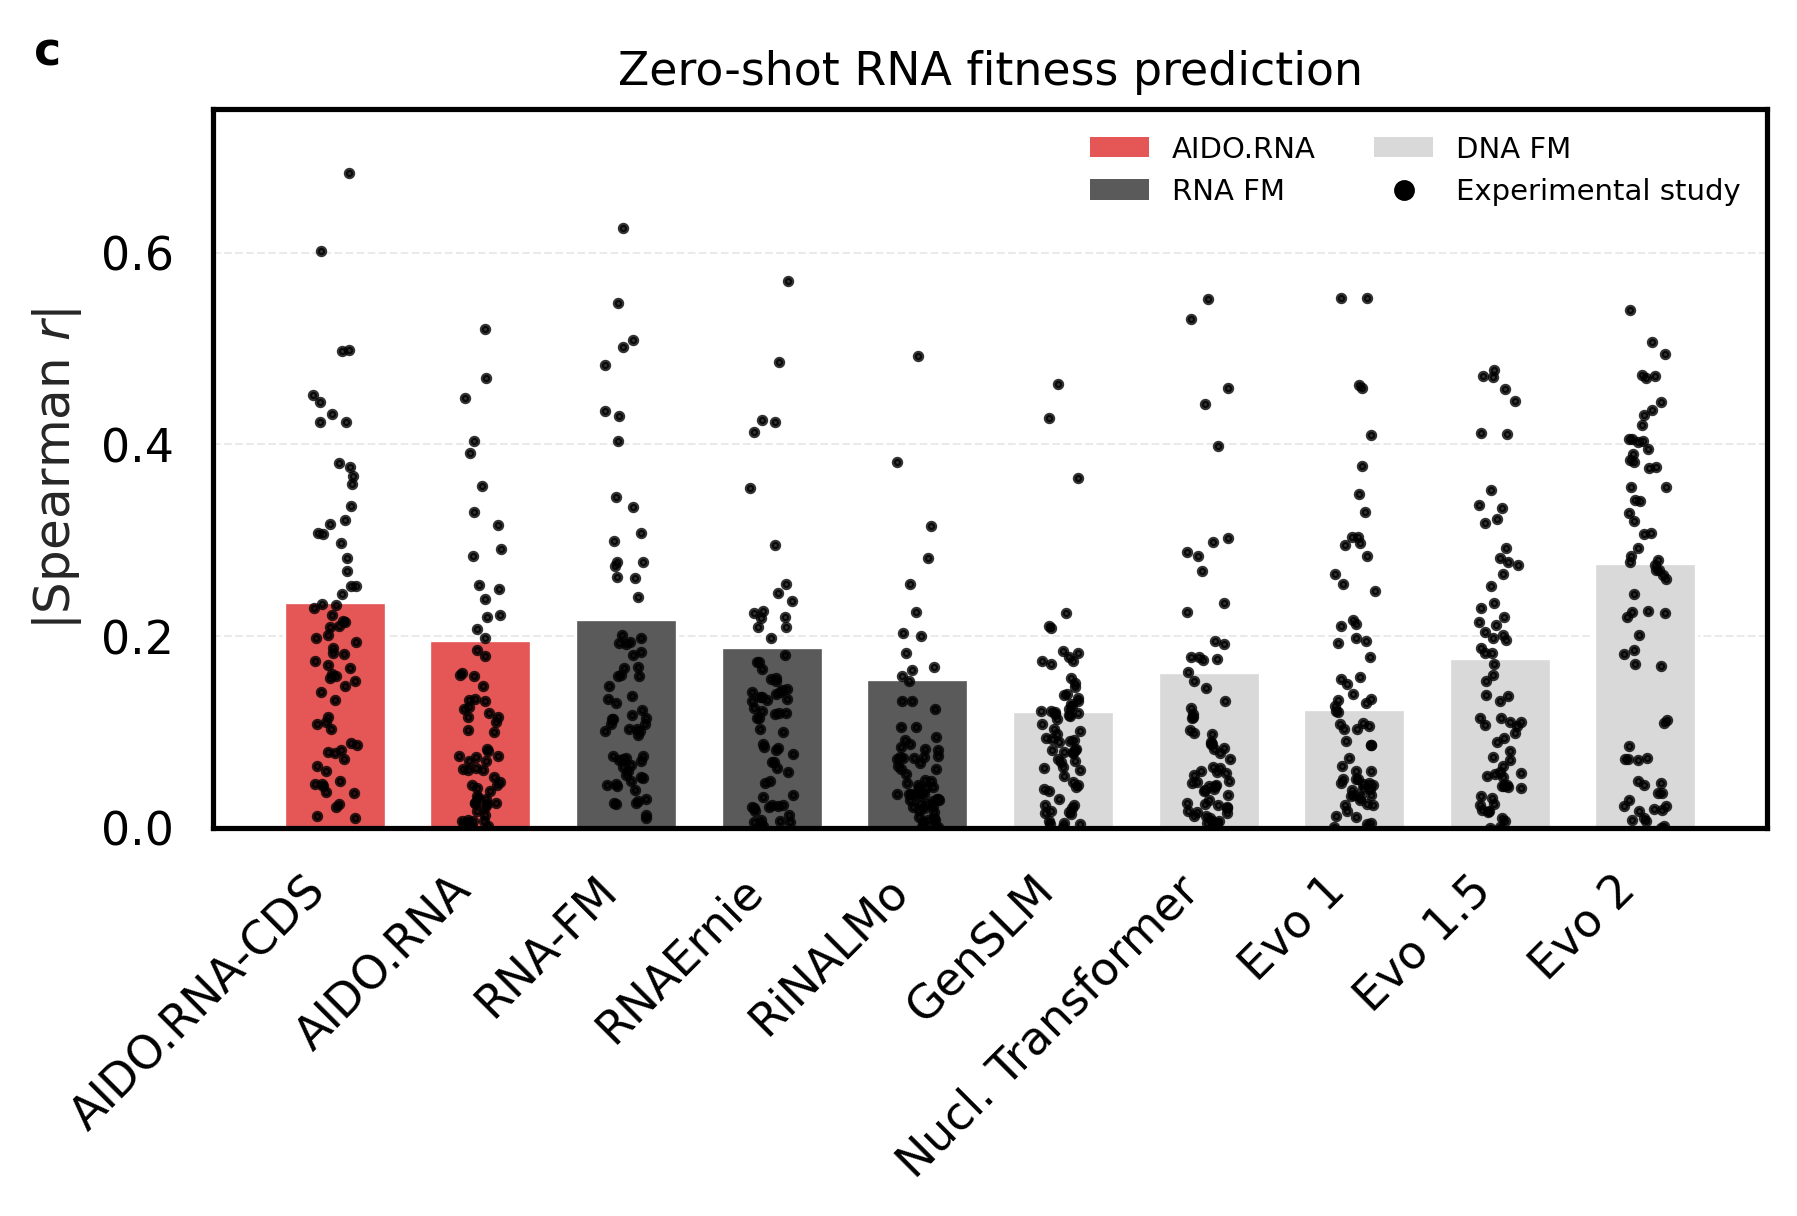

In [33]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

x = np.arange(len(model_list))

# Colors: highlight our models
# colors = ["#abc08d"]*2 + ["#5A5A5A"] * 3 + ["#D9D9D9"] * 5
colors = ["#E45756"]*2 + ["#5A5A5A"] * 3 + ["#D9D9D9"] * 5

# Bar plot
bars = ax.bar(
    x,
    means,
    color=colors,
    # edgecolor="black",
    linewidth=0.8,
    width=0.7,
    zorder=2
)

# Overlay experimental points
for i, vals in enumerate(points):
    jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(
        np.full_like(vals, x[i]) + jitter,
        vals,
        color="black",
        s=3,
        alpha=0.8,
        zorder=3
)


# Axis formatting
ax.set_ylabel("|Spearman $r$|")
ax.set_title("Zero-shot RNA fitness prediction", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(model_list, rotation=45, ha="right")

ax.set_ylim(0, 0.75)

# Clean style
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4, zorder=0)

# label figure
fig.text(
    0.02, 0.99,
    "c",
    ha="left",
    va="top",
    fontsize=11,
    fontweight="bold"
)

legend_elements = [
    Patch(facecolor="#E45756", edgecolor="none", label="AIDO.RNA"),
    Patch(facecolor="#5A5A5A", edgecolor="none", label="RNA FM"),
    Patch(facecolor="#D9D9D9", edgecolor="none", label="DNA FM"),
    Line2D([0], [0], marker="o", color="black", linestyle="None",
           markersize=4, label="Experimental study")
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    loc="upper right",
    # bbox_to_anchor=(1, -0.3),
    ncol=2,
    fontsize=7
)

plt.tight_layout()
plt.show()
fig.savefig("/lustre/scratch/shared-folders/bio_project/shuxian/gbft/mg/rna_202507/interpretation/figures/rna_fitness_overall.png", dpi=600, bbox_inches='tight')

## Plot heatmap for each RNA type

In [23]:
heat_df = fitness.sort_values("All", ascending=False).iloc[:, :-2]
heat_df

,Model,mRNA-splicing,mRNA-coding,tRNA,Aptamer,Ribozyme
9,Evo 2,0.431365,0.270436,0.386735,0.119205,0.172115
0,AIDO.RNA-CDS,0.132377,0.201075,0.485615,0.144956,0.212251
2,RNA-FM,0.103378,0.129171,0.463768,0.190264,0.200836
1,AIDO.RNA,0.157137,0.078221,0.411209,0.169109,0.163542
3,RNAErnie,0.230081,0.117475,0.416115,0.037492,0.141794
8,Evo 1.5,0.131077,0.157303,0.384997,0.043954,0.169016
6,Nucl. Transformer,0.120814,0.082897,0.316607,0.146460,0.146615
4,RiNALMo,0.348358,0.070085,0.259706,0.025864,0.072228
7,Evo 1,0.133845,0.160823,0.155498,0.034535,0.136566
5,GenSLM,0.173388,0.083511,0.093373,0.125714,0.135365


In [24]:
heat_df = heat_df.set_index("Model")
heat_df

,mRNA-splicing,mRNA-coding,tRNA,Aptamer,Ribozyme
Model,,,,,
Evo 2,0.431365,0.270436,0.386735,0.119205,0.172115
AIDO.RNA-CDS,0.132377,0.201075,0.485615,0.144956,0.212251
RNA-FM,0.103378,0.129171,0.463768,0.190264,0.200836
AIDO.RNA,0.157137,0.078221,0.411209,0.169109,0.163542
RNAErnie,0.230081,0.117475,0.416115,0.037492,0.141794
Evo 1.5,0.131077,0.157303,0.384997,0.043954,0.169016
Nucl. Transformer,0.120814,0.082897,0.316607,0.146460,0.146615
RiNALMo,0.348358,0.070085,0.259706,0.025864,0.072228
Evo 1,0.133845,0.160823,0.155498,0.034535,0.136566


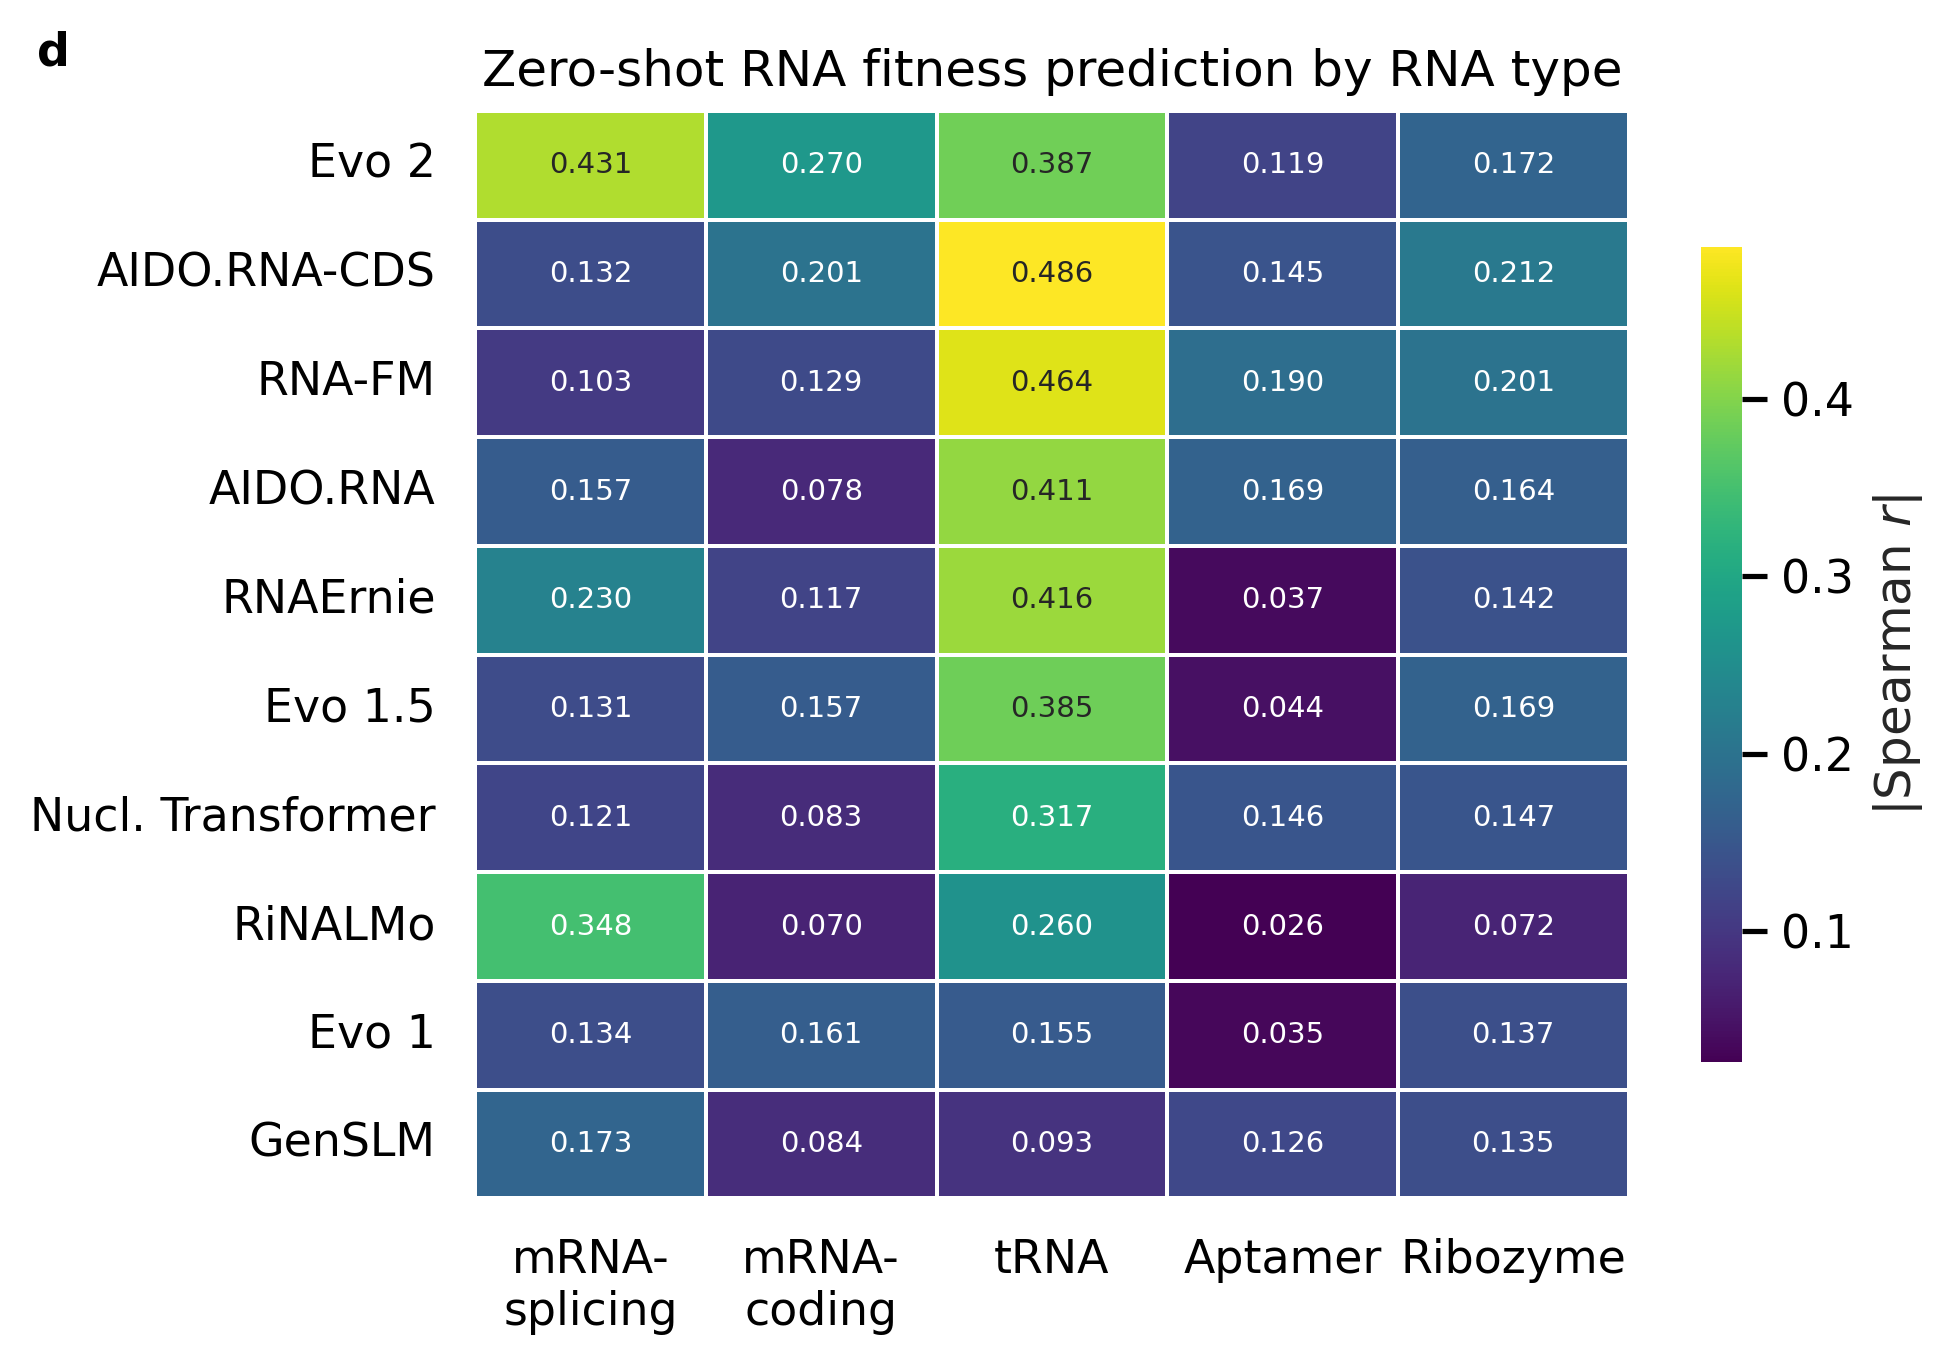

In [32]:
# plot heat map among different RNA types and models

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

# Heatmap
hm = sns.heatmap(
    heat_df,
    cmap="viridis",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "|Spearman $r$|", "shrink": 0.75},
    ax=ax
)

# Axis labels & title
# ax.set_xlabel("RNA type")
ax.set_ylabel("")
ax.set_title("Zero-shot RNA fitness prediction by RNA type") #fontsize=10)

# Rotate x labels
# ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
# Wrap long labels for x-axis
wrapped_labels = ['\n'.join(textwrap.wrap(label, 10)) for label in heat_df.columns.values.tolist()]
ax.set_xticklabels(wrapped_labels, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

fig.text(
    0.02, 0.99,
    "d",
    ha="left",
    va="top",
    fontsize=11,
    fontweight="bold"
)

# Highlight AIDO.RNA rows
# for i, model in enumerate(heat_df.index):
#     if model.startswith("AIDO.RNA"):
#         ax.add_patch(
#             plt.Rectangle(
#                 (0, i),
#                 heat_df.shape[1],
#                 1,
#                 fill=False,
#                 edgecolor="#abc08d",
#                 linewidth=1.2
#             )
#         )

plt.tight_layout()
plt.show()
fig.savefig("/lustre/scratch/shared-folders/bio_project/shuxian/gbft/mg/rna_202507/interpretation/figures/rna_fitness_heatmap.png", dpi=600, bbox_inches='tight')